In [1]:
# Install/update Kaggle
!pip install -q --upgrade kaggle

# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d puneet6060/intel-image-classification --force

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 2.9 MB/s eta 0:00:00
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 207MB/s]



In [2]:
# Extract dataset
import zipfile
import os

zip_path = "/content/intel-image-classification.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.vgg16 import VGG16

In [4]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,img_to_array

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    directory='/content/seg_train/seg_train',
    class_mode='sparse',
    batch_size=batch_size,
    target_size=(256, 256)
)

validation_generator = test_datagen.flow_from_directory(
    directory='/content/seg_test/seg_test',
    class_mode='sparse',
    batch_size=batch_size,
    target_size=(256, 256)
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [7]:
conv_base=VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(256,256,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model=Sequential([
    conv_base,
    Flatten(),
    Dense(150,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(75,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(30,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(6,activation='softmax'),
])

In [9]:
conv_base.trainable=False

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 150)            │     4,915,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150)            │           600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 75)             │        11,325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75)             │           300 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           186 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,644,849 (74.94 MB)

 Trainable params: 4,929,651 (18.81 MB)

 Non-trainable params: 14,715,198 (56.13 MB)

In [11]:
model.compile(optimizer='adam',metrics=['accuracy'],loss='sparse_categorical_crossentropy')

In [12]:
callback=EarlyStopping(
    monitor='val_loss',
    verbose=1,
    mode='min',
    min_delta=0.01,
    patience=5,
    restore_best_weights=True
)

In [13]:
history=model.fit(train_generator,verbose=1,validation_data=validation_generator,epochs=100,callbacks=callback,batch_size=32)

Epoch 1/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 343s 723ms/step - accuracy: 0.7489 - loss: 0.6870 - val_accuracy: 0.8467 - val_loss: 0.4141
Epoch 2/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 281s 641ms/step - accuracy: 0.8228 - loss: 0.4953 - val_accuracy: 0.8647 - val_loss: 0.3585
Epoch 3/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 283s 645ms/step - accuracy: 0.8362 - loss: 0.4614 - val_accuracy: 0.8887 - val_loss: 0.3230
Epoch 4/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 281s 640ms/step - accuracy: 0.8499 - loss: 0.4326 - val_accuracy: 0.8823 - val_loss: 0.3314
Epoch 5/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 280s 638ms/step - accuracy: 0.8572 - loss: 0.4057 - val_accuracy: 0.8660 - val_loss: 0.3681
Epoch 6/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 275s 625ms/step - accuracy: 0.8553 - loss: 0.4018 - val_accuracy: 0.8690 - val_loss: 0.3597
Epoch 7/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 276s 629ms/step - accuracy: 0.8592 - loss: 0.3952 - val_accuracy: 0.8793 - val_loss: 0.3428
Epoch 8/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 282s 642ms/step - accuracy: 

In [14]:
import matplotlib.pyplot as plt

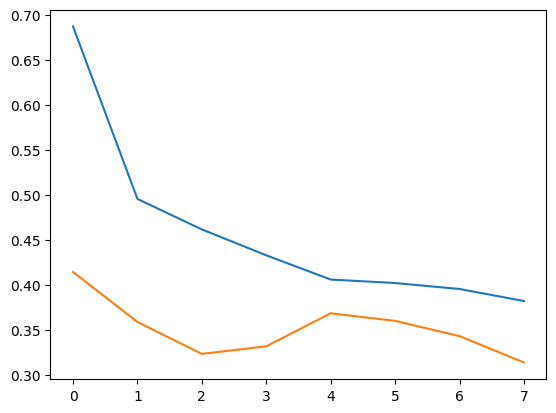

In [15]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')

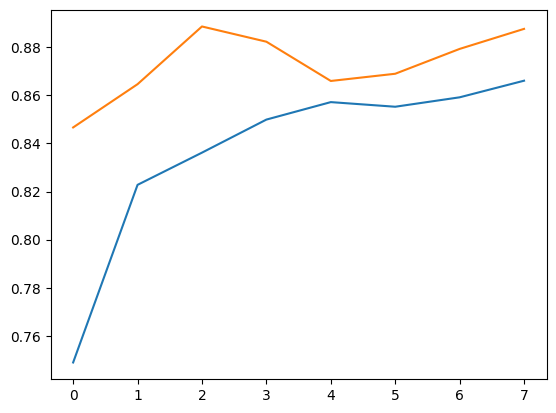

In [16]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')